In [1]:
import easyMPRA_20231003 as em

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pickle

from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import accuracy_score
from sklearn.metrics import hamming_loss



import js

from _helper_functions import read_tsv
from _helper_functions import zipdf
from _helper_functions import cb
from _helper_functions import revcomp
from _helper_functions import dprint


pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)


loading libraries...
done!


# Load data

In [17]:

endf=pd.read_pickle(f'01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rpmOnly.laneAvg.seqrunAvg.pd.df.pickle')


In [18]:
endf.head()

,enhancer-seq,enhancer-id,rpm-R1,rpm-R2,rpm-R3,rpm-D1,rpm-D2,rpm-D3
0,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGC...,ABL_S5-G3F-S1-G2F-S2-E2F-S4-E1F-S3-G1F-S6,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, 0.40997714349454295,...","[0.009548078436808582, 0.010138183514233387, 0...","[0.010964341334202054, 0.010364966278965992, 0...","[0.012972302210823565, 0.009054785310606234, 0..."
1,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACGC...,ABL_S5-G3F-S1-G2F-S2-E2F-S4-E1F-S3-G1R-S6,"[nan, nan, nan, nan, nan, nan, 0.4442479613544...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.01645939976988968, 0.017446301363873602, 0....","[nan, 0.014648702507907799, 0.0186950214240407...","[0.020134559160807433, 0.020357562095117385, 0..."
2,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTT...,ABL_S5-G3F-S1-G2F-S2-E2F-S4-E1R-S3-G1F-S6,"[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, 0.0913141604083...","[0.047586759879867005, 0.01698084619641469, 0....","[0.007963971365679806, 0.008951557335371785, 0...","[0.0470357455213438, 0.009539871020414257, 0.0..."
3,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCACTT...,ABL_S5-G3F-S1-G2F-S2-E2F-S4-E1R-S3-G1R-S6,"[nan, nan, 0.3322198763113125, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.007616430267936355, 0.023808599094273013, 0...","[0.008827144049979172, 0.04100436766529071, 0....","[0.010984881701434066, 0.018120584231394586, 0..."
4,AAAATAGGCATCTGAAGCTCAAATATTTAAAGCAAATTGCTCGAAA...,ABL_S5-G3F-S1-G2F-S2-E2F-S4-G1F-S3-E1F-S6,"[nan, nan, nan, 0.1169953066983254, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[nan, nan, nan, nan, nan, nan, nan, nan, nan, ...","[0.029177850965170504, 0.0343671455753111, 0.0...","[0.03291508885223336, 0.056913867466090666, 0....","[0.03545514126052256, 0.029366101864285853, 0...."


In [19]:
# remove any barcodes not detected in DNA

# this code omits rna measuremnts if the same barcode in DNA is not detected

scaffold='rpm-{nt}{rep}'

for rep in ['1','2','3']:
    
    dna=scaffold.replace('{nt}','D').replace('{rep}',rep)
    rna=scaffold.replace('{nt}','R').replace('{rep}',rep)
    
    
    endf[rna+'-filtNa-Dnotnull'],\
    endf[dna+'-filtNa-Dnotnull']=\
    em.filter_na_matched(indf=endf,
                         col1=rna,
                         col2=dna,
                         treatNaType={rna:'zero',dna:'omit'})
    

In [20]:
# calculte pooled activity as sum(RNA)/sum(DNA)

minActivityToCount=.5 # remove any replicates with activity below .5 

filtstyle='-filtNa-Dnotnull'
               
scaffold='rpm-{nt}{rep}'
    
newSumActCols=[]
newLenActCols=[]
newRnaLenActCols=[]

for rep in ['1','2','3']:

    rna = scaffold.replace('{nt}','R').replace('{rep}',rep) + filtstyle
    dna = scaffold.replace('{nt}','D').replace('{rep}',rep) + filtstyle
    
    rnasum = rna+'-sum'
    dnasum = dna+'-sum'        
    rnalen = rna+'-lenNonZero'
    dnalen = dna+'-len'        

    endf[rnasum] = endf[rna].apply(sum)
    endf[dnasum] = endf[dna].apply(sum)
    endf[rnalen] = endf[rna].apply(lambda l: len([i for i in l if i!=0]))
    endf[dnalen] = endf[dna].apply(lambda l: len(l))
    
    newcol=f'pool-sumR/sumD-{rep}{filtstyle}'
    newSumActCols.append(newcol)
    endf[newcol] = endf[rnasum] / endf[dnasum]

endf[f'pool-sumR/sumD-sum{filtstyle}'] = endf[newSumActCols].sum( axis=1, skipna=True)

endf[f'pool-sumR/sumD-123{filtstyle}'] = em.concat_sample_values(endf,newSumActCols)
endf[f'pool-sumR/sumD-123{filtstyle}-minActFilt{minActivityToCount}'] = em.mask_na_filter(endf,f'pool-sumR/sumD-123{filtstyle}',minVal=minActivityToCount,filterType='min')
endf[f'pool-sumR/sumD-sum{filtstyle}-minActFilt{minActivityToCount}'] = endf[f'pool-sumR/sumD-123{filtstyle}-minActFilt{minActivityToCount}'].apply(lambda l: sum    ([li for li in l if pd.notnull(li)]) if len([li for li in l if pd.notnull(li)])>0 else np.NaN)

In [21]:
endf[f'pool-sumR/sumD-sum{filtstyle}-minActFilt{minActivityToCount}-log2']=endf[f'pool-sumR/sumD-sum{filtstyle}-minActFilt{minActivityToCount}'].apply(lambda act: np.log2(act))

In [22]:
pctlmin,pctlmax=(45,85)


In [23]:
# rescale activities to be between the 45th and 85th percentiles
endf=endf.reset_index(drop=False).set_index('enhancer-seq')

activityColName=f'pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt{minActivityToCount}-log2'
# activityName='Log2\nSum(RNA)/Num(DNA)\nExp Wide Avg\nFilter out reps with <.5'
# plotTitle=''

thresholdToLabelPositives = np.percentile(endf[activityColName].dropna(), pctlmax)
thresholdToLabelNegatives = np.percentile(endf[activityColName].dropna(), pctlmin)

# Calculate the range for scaling
scaling_range = thresholdToLabelPositives - thresholdToLabelNegatives

endf[activityColName+'-rescaled'] = endf[activityColName].apply(lambda a:(a - thresholdToLabelNegatives) / scaling_range)

Text(0.5, 0, 'activity before rescale')

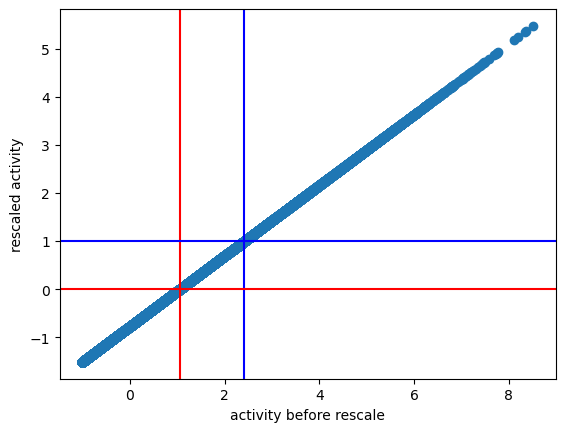

In [24]:
# show how rescaling doesnt effect the underlying distribution of activities
#  we rescale to make inert below 0 and active above 1 for an inuitive way to interpret activities

fig,ax=plt.subplots(1)

ax.scatter(endf[activityColName],endf[activityColName+'-rescaled'])
ax.axvline(thresholdToLabelNegatives,color='red')
ax.axvline(thresholdToLabelPositives,color='blue')
ax.axhline(0,color='red')
ax.axhline(1,color='blue')

ax.set_ylabel('rescaled activity')
ax.set_xlabel('activity before rescale')

# Collapse on wild-type elements

In [25]:
# load ref dict
fn='reference-files//Ols2OlsAblated.pydict.pickle'
with open(fn,'rb') as f: Ols2OlsAblated=pickle.load(f)
dprint(Ols2OlsAblated)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATTGCTCAATATTTAAAATAGGA


In [26]:
# load ref dict
fn='reference-files//OlsEnSeq2Id.pydict.pickle'
with open(fn,'rb') as f: OlsEnSeq2Id=pickle.load(f)
dprint(OlsEnSeq2Id)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA Otx-a WT


In [27]:
# load ref dict
fn='reference-files//OLSEnSeq2Name.pydict.pickle'
with open(fn,'rb') as f: OLSEnSeq2Name=pickle.load(f)
dprint(OLSEnSeq2Name)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6


In [28]:
# load ref dict
fn='reference-files//Ols2OlsAblated.pydict.pickle'
with open(fn,'rb') as f: Ols2OlsAblated=pickle.load(f)
dprint(Ols2OlsAblated)

CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATTGCTCAATATCTAAGATAGGA CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATTGCTCAATATTTAAAATAGGA


In [29]:
def get_change_label(wt,abl):

    if    wt>=1: wtlabel=1
    elif  wt<=0: wtlabel=-1
    else:        wtlabel=0
    
    if    abl>=1: abllabel=1
    elif  abl<=0: abllabel=-1
    else:         abllabel=0
    
    return wtlabel,abllabel
    

In [30]:
# create dataframe where each row is the wild-type element and the ablated activity is included as another column

outcols=[
 'enhancer-id',
 'enhancer-sites',
 'wt-enhancer-seq',
 'wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled',
 'abl-enhancer-seq',
 'abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']

c2v={c:[] for c in outcols}

for wtseq,ablseq in Ols2OlsAblated.items():
        
    # wt activity
    if wtseq in endf.index: wtact=endf.at[wtseq,'pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']
    else:                   wtact=np.NaN
        
    # abl activity
    if ablseq in endf.index: ablact=endf.at[ablseq,'pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled']
    else:                    ablact=np.NaN
     
    c2v['enhancer-id'].append(OlsEnSeq2Id[wtseq])
    c2v['enhancer-sites'].append(OLSEnSeq2Name[wtseq])
    c2v['wt-enhancer-seq'].append(wtseq)
    c2v['wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].append(wtact)
    c2v['abl-enhancer-seq'].append(ablseq)
    c2v['abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'].append(ablact)
    
wtactcol,ablactcol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled','abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

wtendf=pd.DataFrame(c2v)

changelabels=[]
for wt,abl in zipdf(wtendf,[wtactcol,ablactcol]):
    
    # if ablated isn't detected, set activity to 0
    if pd.isnull(abl): abl=0
        
    changelabels.append(get_change_label(wt,abl))
    
wtendf['act-change-bin']=changelabels
wtendf['enhancer-dependent-gata-ets']=wtendf['act-change-bin'].apply(lambda changelabels: int(changelabels==(1,-1)))

In [37]:
wtendf.to_pickle(f'01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rescaledPctl_{pctlmin}_{pctlmax}.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle')
wtendf.to_csv(   f'01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rescaledPctl_{pctlmin}_{pctlmax}.wtcollapsed.sumRnaDivSumDna-repSum.tsv',sep='\t',index=None)

# Calculate activity score

In [38]:
# if starting here
endf=pd.read_pickle('01-Calculate-Enhancer-Activity-Levels/02-generated-tables//endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle').set_index('enhancer-id')


In [40]:
endf.head()

,enhancer-sites,wt-enhancer-seq,wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,abl-enhancer-seq,abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled,act-change-bin,enhancer-dependent-gata-ets
enhancer-id,,,,,,,
Otx-a WT,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,1.197798,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.848065,"(1, 0)",0
ORL351560,L1-G1F-L2-E1F-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGAGATAACTAACGGAAGTTTTCGAAAAGGAAATT...,0.856235,CATCTGAAGCTCGAAATAACTAACGCAAGTTTTCGAAAAGCAAATT...,-1.100699,"(0, -1)",0
ORL108031,L1-G1R-L2-E1F-L3-E2F-L4-G2F-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,0.777169,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,0.706492,"(0, 0)",0
ORL414244,L1-G1R-L2-E1F-L3-E2F-L4-G2R-L5-G3R-L6,CATCTGAAGCTCGTTATCTCTAACGGAAGTTTTCGAAAAGGAAATT...,NaN,CATCTGAAGCTCGTTATTTCTAACGCAAGTTTTCGAAAAGCAAATT...,-1.486866,"(0, -1)",0
ORL280162,L1-G1R-L2-E1R-L3-E2F-L4-G2R-L5-G3F-L6,CATCTGAAGCTCGTTATCTCTAACTTCCGTTTTCGAAAAGGAAATT...,0.518839,CATCTGAAGCTCGTTATTTCTAACTTGCGTTTTCGAAAAGCAAATT...,-1.322202,"(0, -1)",0


# Fig 2C: Plotting activity of known controls

In [2]:
# if youre starting here
endf=pd.read_pickle(f'./01-Calculate-Enhancer-Activity-Levels/02-generated-tables/endf.rescaledPctl_45_85.wtcollapsed.sumRnaDivSumDna-repSum.pd.df.pickle').set_index('enhancer-id')

In [3]:
fn='reference-files/microscope-controls.tsv'
!head {fn}

Microscope Label	Sequence
Inert	TGCTCACTTGCGTTACCTATTTTTTTCGAAGAAATAACCATCTGAAGCTCAAATATTATTTGCTTA
Inert	CATCTGAAGCTCGTTATTTCTGCTCCCTATTTTTTTCGAAATTTGCTTTAACTTGCGTAAATATTA
Neural	CATCTGAAGCTCACGGAAGTTGCTCGTTATCTCTTTCGAACCTATCTTATTTCCTTTAAGATATTA
Neural	TTTCGAAAATATCTCCTATCTTCATCTGAAGCTCGTTATCTCTAAAGGAAATTGCTCACGGAAGTA
Inert	AAGATAGGTGCTCAAGGAAATTAAGATATTTTTCGAAGAGATAACCATCTGAAGCTCACTTCCGTA
Inert	TTTCGAAATTTCCTTCATCTGAAGCTCGAGATAACACGGAAGTTGCTCAATATCTTACCTATCTTA
Neural	CATCTGAAGCTCAAGATAGGGAGATAACTGCTCACGGAAGTTTTCGAAAATATCTTAAAGGAAATA
Inert	CATCTGAAGCTCATTTGCTTTTTCGAACCTATTTTTGCTCAATATTTACGCAAGTTAGAAATAACA
Neural	AGATATTTGCTCGAGATAACCATCTGAAGCTCACTTCCGTTAATTTCCTTTTTCGAAAAGATAGGA


In [4]:
# map sequence to control ref info
seq2label={}
for label,sequence in read_tsv(fn,pc=False,header=True):
    seq2label[sequence]=label
dprint(seq2label)

TGCTCACTTGCGTTACCTATTTTTTTCGAAGAAATAACCATCTGAAGCTCAAATATTATTTGCTTA Inert


	prepping/plotting control data...


/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead
  if pd.api.types.is_categorical_dtype(vector):
/tscc/nfs/home/solvason/miniconda/envs/notebook1/lib/python3.11/site-packages/seaborn/_oldcore.py:1498: FutureWarning: is_categ

[]

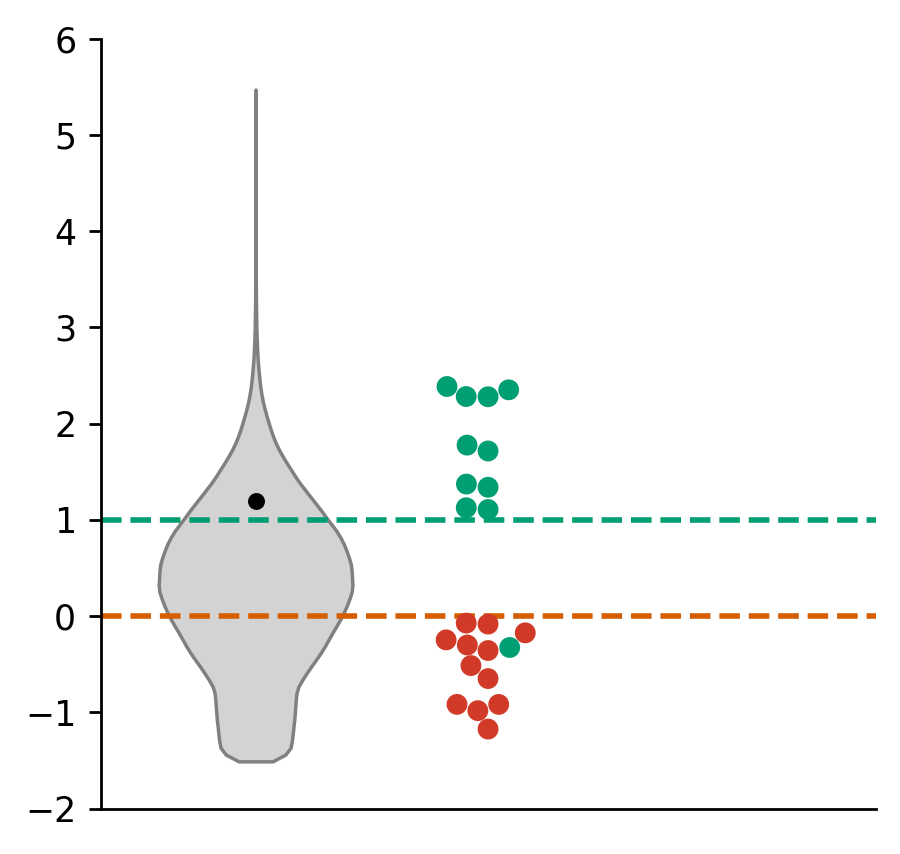

In [5]:
activityColName='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'

activityName=activityColName
thresholdToLabelPositives = 1
thresholdToLabelNegatives = 0

plot_legend=False

####################################################################################
# Creaete DFs
####################################################################################

c2v={c:[] for c in ['seq','act','func']}

for wtseq,ablseq,wtact,ablact in zipdf(endf,['wt-enhancer-seq',
                                             'abl-enhancer-seq',
                                             activityColName,
                                             activityColName.replace('wt','abl')]):
    
    if wtseq in seq2label:
        seq=wtseq
        act=wtact
        func=seq2label[wtseq]
 
        c2v['seq'].append(seq)        
        c2v['func'].append(func)        
        c2v['act'].append(act)
        
    if ablseq in seq2label:
        seq=ablseq
        act=ablact
        func=seq2label[ablseq]
        
        c2v['seq'].append(seq)        
        c2v['func'].append(func)        
        c2v['act'].append(act)
        
ctrlDF=pd.DataFrame(c2v)

####################################################################################
# Plot all activities
####################################################################################

activity=activityColName

fig,ax=plt.subplots(1,figsize=(4,4),dpi=250)

ax.set_xlim(-.5,.25)

#################################
# plot all activity
#################################

violinpos=-.3

data=endf[activity].dropna().tolist()

parts=ax.violinplot(data,positions=[violinpos],widths=[.25],showmeans=False, showmedians=False, showextrema=False)

ax.scatter(violinpos,endf.at['Otx-a WT',activity],s=15,color='black')

for pc in parts['bodies']:
    pc.set_facecolor('lightgrey')
    pc.set_edgecolor('grey')
    pc.set_alpha(1)

ax.set_ylabel(activityName)
ax.set_xlabel('')

ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)


#################################
# plot controls
#################################

print('\tprepping/plotting control data...')

# Create DF for swarmplot (groups on different X)
c2v={'function':ctrlDF.func,'X':[0 for func in ctrlDF.func],'Y':ctrlDF['act']}

swarmDF=pd.DataFrame(c2v)

sns.swarmplot(data=swarmDF,x='X',y='Y',hue='function',ax=ax,palette={'Neural':cb['green'],'Inert':cb['orangenature']},size=6)
ax.spines.right.set_visible(False)
ax.spines.top.set_visible(False)

####################################################################################
# Legend
####################################################################################

if plot_legend:
    handles,labels = ax.get_legend_handles_labels()
    order=['Neural + Ectopic Expression','Neural Enhancer','Weak Neural Enhancer','Non-Functional']
    order=[labels.index(fxn) for fxn in order if fxn in labels]
    plt.legend([handles[i] for i in order],[labels[i] for i in order],bbox_to_anchor=(1,1))
else: ax.get_legend().remove()

# ####################################################################################
# # Plot thresholds for classification
# ####################################################################################

ax.axhline(thresholdToLabelPositives,color=cb['green'],ls='--',lw=1.6)
ax.axhline(thresholdToLabelNegatives,color=cb['red'],ls='--',  lw=1.6)

ax.set_ylabel(activityName)

ax.set_ylim(-2,6)

ax.set_ylabel('')

ax.set_xlabel('')
ax.set_xticks([])
ax.set_xticklabels([])



# Fig 2E: Plotting enhancers dependent on ETS and GATA

[Text(0, 0, 'wt element'), Text(1, 0, 'abl element')]

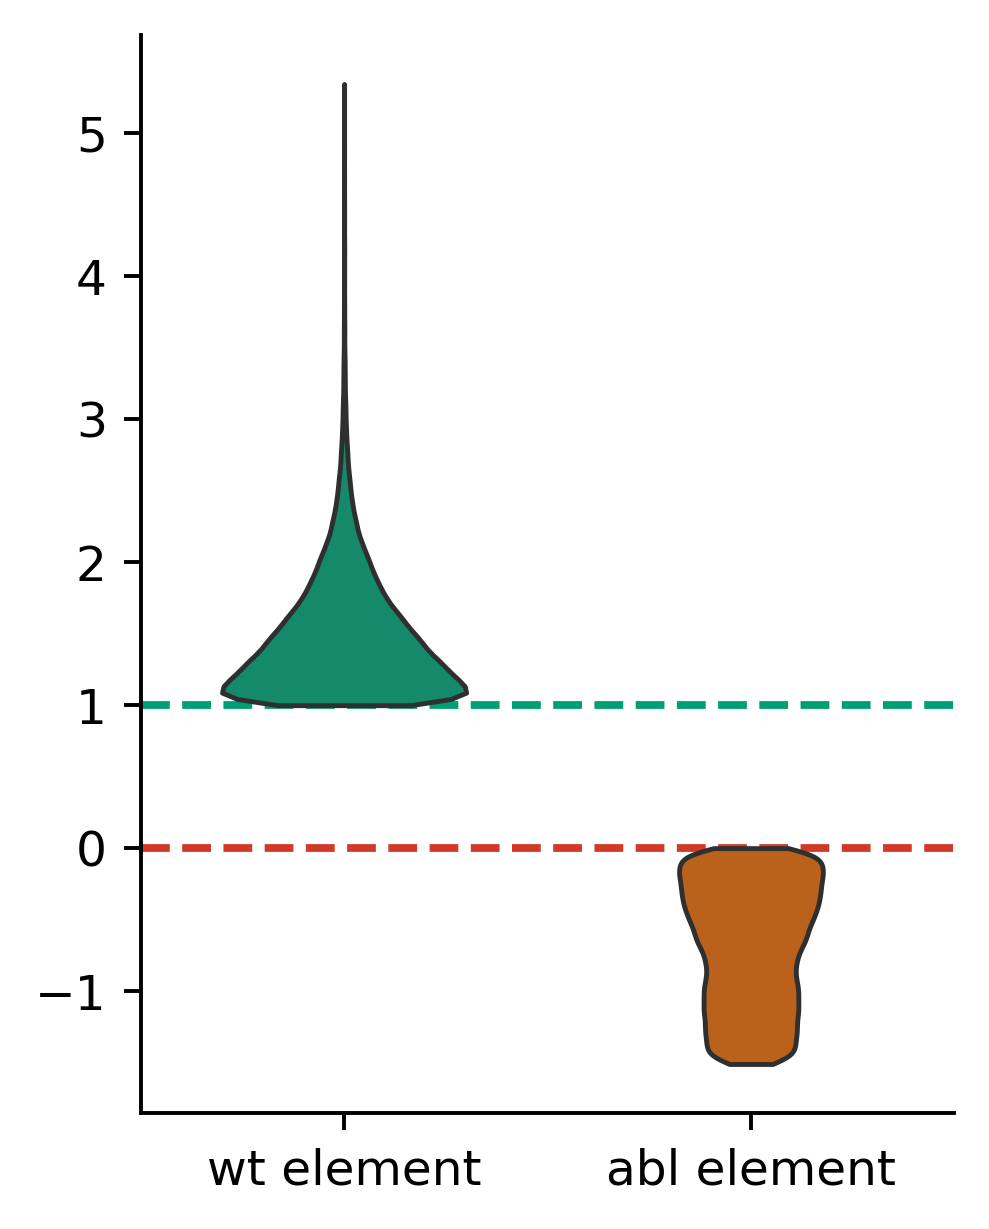

In [10]:

wtactcol='wt-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
ablactcol='abl-pool-sumR/sumD-sum-filtNa-Dnotnull-minActFilt0.5-log2-rescaled'
wtActs=[]
ablActs=[]
changelabel=(1,-1) # ie, the wt enhancer is active and the ablated is inert
    
tempdf=endf.loc[endf['act-change-bin']==(1,-1),:]

for wt,abl in zipdf(tempdf,[wtactcol,ablactcol]):
    
    wtActs.append(wt)
    ablActs.append(abl)
    
fig,ax=plt.subplots(1,1,figsize=(3,4),dpi=350)

sns.violinplot(data=[wtActs,ablActs],palette=[cb['green'],cb['red']],ax=ax,linewidth=1,cut=0,inner=None,width=.6,scale='area')
    
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.axhline(0,color=cb['orangenature'] ,lw=1.6,ls='--',alpha=1,zorder=0)
ax.axhline(1,color=cb['green'],  lw=1.6,ls='--',alpha=1,zorder=0)
    

ax.set_xticklabels(['wt element','abl element'])
